In [9]:
import zipfile

with zipfile.ZipFile("student (1).zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Extracted successfully!")

Extracted successfully!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Shape and data types
print("\nShape after cleaning:", df.shape)
print("\nData types:")
print(df.dtypes)

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Shape after cleaning: (395, 33)

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup

## Step 1: Load Dataset
Dataset load kiya pandas se. File semicolon (;) separated thi isliye sep=';' use kiya. Dataset mein 395 rows aur 33 columns hain.

## Step 2: Explore & Clean Data
Dataset mein koi missing values nahi hain aur koi duplicate rows bhi nahi hain — dataset already clean hai analysis ke liye.

In [12]:
average_g3 = df['G3'].mean()
print(f"Average Final Grade (G3): {average_g3:.2f}")

Average Final Grade (G3): 10.42


In [13]:
above_15 = df[df['G3'] > 15].shape[0]
percentage = (above_15 / df.shape[0]) * 100
print(f"Number of students who scored above 15: {above_15}")
print(f"Percentage of students: {percentage:.2f}%")

Number of students who scored above 15: 40
Percentage of students: 10.13%


In [14]:
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between studytime and G3: {correlation:.3f}")

if correlation > 0.3:
    strength = "moderate positive"
elif correlation > 0:
    strength = "weak positive"
elif correlation < -0.3:
    strength = "moderate negative"
else:
    strength = "very weak/negligible"

print(f"This indicates a {strength} relationship between study time and final grade.")

Correlation between studytime and G3: 0.098
This indicates a weak positive relationship between study time and final grade.


In [15]:
gender_performance = df.groupby('sex')['G3'].mean()
print("Average Final Grade by Gender:")
print(gender_performance)

better_gender = gender_performance.idxmax()
gender_map = {'M': 'Male', 'F': 'Female'}
print(f"\n{gender_map[better_gender]} students perform better on average.")

Average Final Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

Male students perform better on average.


## Analysis Results
- Average final grade (G3) 10.42 hai
- 40 students (10.13%) ne 15 se upar score kiya
- Study time aur grade ke beech weak positive correlation (0.098) hai — study time badhne se grade thoda better hota hai lekin bahut strong factor nahi hai
- Male students (10.91) female students (9.97) se average mein better perform karte hain

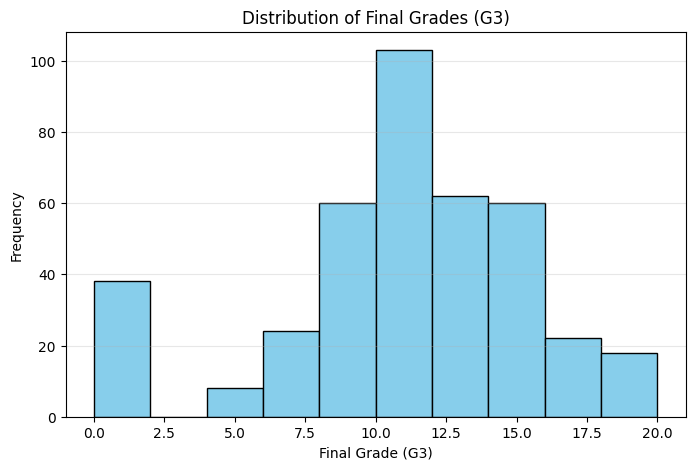

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

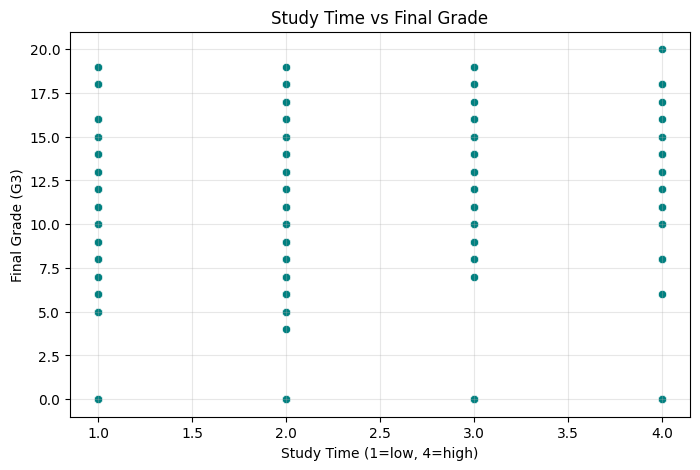

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='studytime', y='G3', data=df, color='teal')
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=low, 4=high)")
plt.ylabel("Final Grade (G3)")
plt.grid(alpha=0.3)
plt.show()

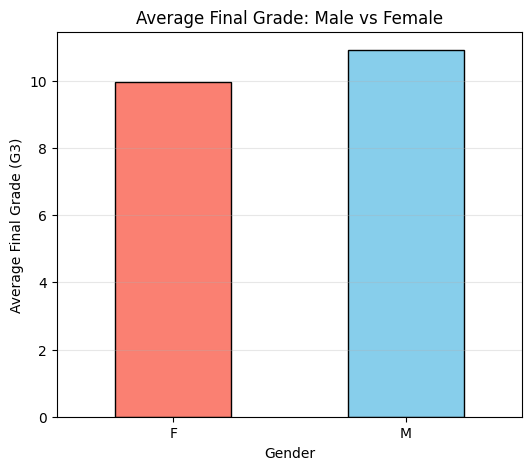

In [18]:
plt.figure(figsize=(6,5))
gender_performance.plot(kind='bar', color=['salmon', 'skyblue'], edgecolor='black')
plt.title("Average Final Grade: Male vs Female")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Conclusion & Summary

- Dataset (student-mat.csv) mein 395 students aur 33 features hain, koi cleaning ki zaroorat nahi thi (0 missing values, 0 duplicates)
- Average final grade (G3) 10.42 hai
- 40 students (10.13%) ne 15 se upar score kiya — ye strong performers hain
- Study time aur final grade ke beech weak positive correlation (0.098) hai — zyada padhna helpful hai lekin akela factor nahi hai
- Male students (10.91) average mein Female students (9.97) se better perform karte hain

### Skills Applied
✅ Data loading & cleaning (Pandas)
✅ Statistical analysis with NumPy
✅ Data visualization with Matplotlib/Seaborn
✅ Correlation analysis
✅ Markdown documentation in Jupyter Notebook